# Séance 4 (Notebook A) : Graphes – BFS, DFS, Backtracking, DAG

**Enseignant :** Jean Delpech

**Cours :** Algorithmie et développement dans l'ingénierie des données

**Classe :** M1 Data

**Année scolaire :** 2025/2026

**Dernière mise à jour :** juin 2026

## Objectifs

- Maîtriser les représentations de graphes et savoir choisir selon le contexte
- Implémenter BFS et DFS *from scratch* et comprendre leurs propriétés algorithmiques
- Comprendre le backtracking comme généralisation du DFS
- Appliquer le tri topologique à la modélisation de pipelines de données (DAG)

## Plan

| # | Bloc |
|---|---|
| 1 | Fondamentaux des graphes : terminologie et représentations |
| 2 | BFS : exploration par niveaux |
| 3 | DFS : exploration en profondeur et détection de cycle |
| 4 | Backtracking : problème des N-reines |
| 5 | DAG et tri topologique (Kahn + DFS) |

> **Notebooks complémentaires de cette séance**
> - **Notebook B** : Dijkstra et A* (plus courts chemins pondérés)
> - **Notebook C** : PageRank et marche aléatoire sur graphe


# PARTIE 1 : Fondamentaux des graphes

## 1.1 Terminologie

Un **graphe** G = (V, E) est composé de :
- **V** (*vertices* / sommets) : l'ensemble des nœuds
- **E** (*edges* / arêtes) : l'ensemble des liens entre nœuds

On note **|V| = n** le nombre de sommets et **|E| = m** le nombre d'arêtes.

### Types de graphes

| Critère | Variantes |
|---|---|
| Orientation | **Non orienté** (arête entre u et v = arête entre v et u) / **Orienté** (arc de u vers v ≠ arc de v vers u) |
| Pondération | **Non pondéré** (arête juste présente ou absente) / **Pondéré** (chaque arête a un poids) |
| Cycles | **Acyclique** (aucun chemin ne revient à son point de départ) / **Cyclique** |
| Connexité | **Connexe** (on peut aller de tout sommet à tout autre) / **Non connexe** |

### Vocabulaire essentiel

- **Degré** d'un sommet : nombre d'arêtes incidentes. Dans un graphe orienté : *in-degree* (arcs entrants) et *out-degree* (arcs sortants).
- **Chemin** : séquence de sommets consécutifs reliés par des arêtes.
- **Cycle** : chemin qui revient à son point de départ.
- **DAG** (*Directed Acyclic Graph*) : graphe **orienté** et **acyclique**, structure fondamentale des pipelines de données (Airflow, dbt, Spark).
- **Composante connexe** : sous-ensemble maximal de sommets tous reliés entre eux.

## 1.2 Représentations en mémoire

### Matrice d'adjacence

Tableau 2D de taille **n × n** où `M[i][j] = 1` (ou le poids) si l'arête (i, j) existe, 0 sinon.

### Liste d'adjacence

Dictionnaire où chaque clé est un sommet et sa valeur est la **liste de ses voisins**.

### Comparaison

| Critère | Matrice d'adjacence | Liste d'adjacence |
|---|---|---|
| Espace mémoire | **O(V²)** | **O(V + E)** |
| Vérifier si (u,v) existe | **O(1)** | O(deg(u)) |
| Lister les voisins de u | O(V) | **O(deg(u))** |
| Adapté pour | Graphes **denses** (m ≈ n²) | Graphes **creux** (m << n²) |

> **Réflexe :** réseau social, graphe routier, pipeline data → graphes *creux* → **liste d'adjacence**.

On peut implémenter une classe `Graph` assez générique, où le graphe est représenté par une liste d’adjacence.
Il faut définir les méthodes :
- ajouter un sommet (avec ou sans orientation pour les graphes orientés)
- ajouter une arête (avec ou sans poids pour les graphes pondérés)
- lister les voisins d’un sommet (pondéré ou pas)

Cela ne pose pas de problème particulier, sinon la gestion des orientations, pondérations, si on le souhaite

In [1]:
# Classe Graph générique (liste d'adjacence)
from __future__ import annotations
from collections import defaultdict
from typing import Optional


class Graph:
    """
    Graphe générique représenté par une liste d'adjacence.
    Supporte les graphes orientés/non orientés, pondérés/non pondérés.
    """

    def __init__(self, directed: bool = False):
        self.directed = directed
        self._adj: dict[str, list[tuple[str, float]]] = defaultdict(list)
        self._vertices: set[str] = set()

    def add_vertex(self, u: str) -> None:
        """Ajoute un sommet isolé."""
        self._vertices.add(u)
        if u not in self._adj:
            self._adj[u] = []

    def add_edge(self, u: str, v: str, weight: float = 1.0) -> None:
        """Ajoute une arête (u, v) avec un poids optionnel."""
        self._vertices.update([u, v])
        self._adj[u].append((v, weight))
        if not self.directed:
            self._adj[v].append((u, weight))

    def neighbors(self, u: str) -> list[str]:
        """Retourne la liste des voisins de u (sans les poids)."""
        return [v for v, _ in self._adj[u]]

    def neighbors_weighted(self, u: str) -> list[tuple[str, float]]:
        """Retourne la liste des (voisin, poids) de u."""
        return list(self._adj[u])

    @property
    def vertices(self) -> set[str]:
        return set(self._vertices)

    @property
    def edges(self) -> list[tuple[str, str, float]]:
        """Retourne toutes les arêtes sous forme (u, v, poids)."""
        result, seen = [], set()
        for u in self._adj:
            for v, w in self._adj[u]:
                key = (min(u, v), max(u, v)) if not self.directed else (u, v)
                if key not in seen:
                    result.append((u, v, w))
                    seen.add(key)
        return result

    def __repr__(self) -> str:
        kind = 'Orienté' if self.directed else 'Non orienté'
        lines = [f"Graph ({kind}, {len(self._vertices)} sommets, {len(self.edges)} arêtes)"]
        for u in sorted(self._adj):
            neighbors_str = ', '.join(f"{v}({w})" for v, w in self._adj[u])
            lines.append(f"  {u} → [{neighbors_str}]")
        return '\n'.join(lines)


# Démonstration
g = Graph(directed=False)
for u, v in [('A','B'), ('A','C'), ('B','D'), ('C','D'), ('D','E'), ('B','E')]:
    g.add_edge(u, v)

print(g)
print(f"\nVoisins de A : {g.neighbors('A')}")
print(f"Voisins de D : {g.neighbors('D')}")

Graph (Non orienté, 5 sommets, 6 arêtes)
  A → [B(1.0), C(1.0)]
  B → [A(1.0), D(1.0), E(1.0)]
  C → [A(1.0), D(1.0)]
  D → [B(1.0), C(1.0), E(1.0)]
  E → [D(1.0), B(1.0)]

Voisins de A : ['B', 'C']
Voisins de D : ['B', 'C', 'E']


# PARTIE 2 : BFS (Breadth-First Search)

## 2.1 Principe

Le **BFS** explore le graphe **par niveaux** : il visite d'abord tous les voisins directs du sommet source (distance 1), puis tous leurs voisins non encore visités (distance 2), et ainsi de suite.

Commeon l’a vu pour les arbres, l'outil central est une **file FIFO** (`deque`) : on enfile les voisins découverts, on défile le prochain sommet à traiter.

```
BFS(graphe G, source s) :
    marquer s comme visité
    enfiler s dans la file Q
    tant que Q non vide :
        u ← défiler Q
        pour chaque voisin v de u :
            si v non visité :
                marquer v comme visité
                enregistrer dist[v] = dist[u] + 1
                enfiler v dans Q
```

### Propriétés

| Propriété | Valeur |
|---|---|
| Complexité temps | **O(V + E)** |
| Complexité espace | **O(V)** (file + marquage) |
| Trouve le plus court chemin ? | **Oui** : en nombre d'arêtes (graphe non pondéré) |
| Structure de données clé | **File FIFO** (`collections.deque`) |

La complexité O(V + E) s'explique simplement : chaque sommet est enfilé **une seule fois** (O(V)), et chaque arête est examinée **au plus deux fois** dans un graphe non orienté (O(E)).

> **Lien avec la séance 3 :** la file FIFO est exactement la structure `deque` implémentée au notebook A. BFS *est* un cas d'usage concret de cette structure.

In [2]:
from collections import deque
from typing import Optional


def bfs(
    graph: Graph,
    source: str
) -> tuple[dict[str, int], dict[str, Optional[str]]]:
    """
    Breadth-First Search depuis `source`.

    Returns
    -------
    dist    : dict sommet → distance (en nb d'arêtes) depuis source
    parent  : dict sommet → prédécesseur dans l'arbre BFS (None pour source)
    """
    dist: dict[str, int] = {source: 0}
    parent: dict[str, Optional[str]] = {source: None}
    queue: deque[str] = deque([source])

    while queue:
        u = queue.popleft()                    # O(1) grâce à deque
        for v in graph.neighbors(u):
            if v not in dist:                  # non visité
                dist[v] = dist[u] + 1
                parent[v] = u
                queue.append(v)

    return dist, parent


def bfs_path(parent: dict, source: str, target: str) -> Optional[list[str]]:
    """
    Reconstruit le plus court chemin de source à target
    à partir du dictionnaire parent produit par BFS.
    Returns None si target n'est pas accessible depuis source.
    """
    if target not in parent:
        return None
    path, current = [], target
    while current is not None:
        path.append(current)
        current = parent[current]
    return list(reversed(path))


# ── Démonstration ──────────────────────────────────────────────────
g = Graph(directed=False)
for u, v in [('A','B'), ('A','C'), ('B','D'), ('B','E'), ('C','F'), ('D','G'), ('E','G')]:
    g.add_edge(u, v)

dist, parent = bfs(g, 'A')

print("=== BFS depuis A ===")
print("\nDistances depuis A :")
for v in sorted(dist):
    print(f"  A → {v} : {dist[v]} arête(s)")

path = bfs_path(parent, 'A', 'G')
print(f"\nPlus court chemin A → G : {' → '.join(path)}")

=== BFS depuis A ===

Distances depuis A :
  A → A : 0 arête(s)
  A → B : 1 arête(s)
  A → C : 1 arête(s)
  A → D : 2 arête(s)
  A → E : 2 arête(s)
  A → F : 2 arête(s)
  A → G : 3 arête(s)

Plus court chemin A → G : A → B → D → G


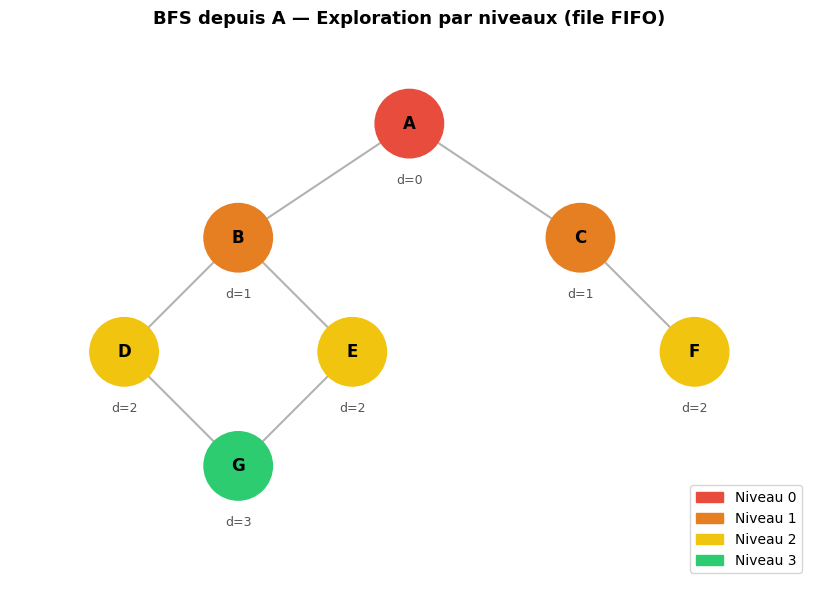

In [3]:
# Visualisation de l'exploration BFS par niveaux

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

levels = dist  # calculé ci-dessus

positions = {
    'A': (0, 0),
    'B': (-1.5, -1), 'C': (1.5, -1),
    'D': (-2.5, -2), 'E': (-0.5, -2), 'F': (2.5, -2),
    'G': (-1.5, -3),
}
level_colors = {0: '#e74c3c', 1: '#e67e22', 2: '#f1c40f', 3: '#2ecc71'}

fig, ax = plt.subplots(figsize=(9, 6))

# Arêtes
for u, v, _ in g.edges:
    x1, y1 = positions[u]; x2, y2 = positions[v]
    ax.plot([x1, x2], [y1, y2], 'k-', alpha=0.3, linewidth=1.5, zorder=1)

# Sommets
for v, (x, y) in positions.items():
    lv = levels.get(v, -1)
    color = level_colors.get(lv, '#bdc3c7')
    ax.add_patch(plt.Circle((x, y), 0.3, color=color, zorder=2))
    ax.text(x, y, v, ha='center', va='center', fontweight='bold', fontsize=12, zorder=3)
    ax.text(x, y - 0.5, f'd={lv}', ha='center', va='center', fontsize=9, color='#555')

patches = [mpatches.Patch(color=c, label=f'Niveau {k}') for k, c in level_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=10)
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-4, 0.8)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('BFS depuis A - Exploration par niveaux (file FIFO)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# PARTIE 3 : DFS (Depth-First Search)

## 3.1 Principe

Le **DFS** explore le graphe **en profondeur** : à chaque sommet, il s'enfonce immédiatement dans un voisin non encore visité avant de revenir en arrière (*backtrack*) pour explorer les autres voisins.

Deux implémentations équivalentes :
- **Récursive** : la pile d'appels (*call stack*) joue le rôle de la pile explicite
- **Itérative** : pile LIFO explicite (`list.append/pop`)

```
DFS_récursif(graphe G, sommet u, visités) :
    marquer u comme visité
    pour chaque voisin v de u :
        si v non visité :
            DFS_récursif(G, v, visités)
```

### Propriétés

| Propriété | Valeur |
|---|---|
| Complexité temps | **O(V + E)** |
| Complexité espace | **O(V)** (pile de récursion) |
| Trouve le plus court chemin ? | **Non** (pas de garantie) |
| Structure de données clé | **Pile LIFO** (ou récursion) |
| Applications | Détection de cycles, tri topologique, composantes fortement connexes |

### BFS vs DFS : quand utiliser lequel ?

| Objectif | Algorithme |
|---|---|
| Plus court chemin (non pondéré) | **BFS** |
| Détection de cycle | **DFS** |
| Tri topologique | **DFS** |
| Trouver tous les nœuds à distance k | **BFS** |
| Backtracking / exploration exhaustive | **DFS** |

In [4]:
def dfs_recursive(
    graph: Graph,
    source: str,
    visited: set | None = None,
    order: list | None = None
) -> list[str]:
    """
    DFS récursif depuis `source`.

    Returns
    -------
    list[str] : ordre de visite des sommets
    """
    if visited is None:
        visited = set()
    if order is None:
        order = []

    visited.add(source)
    order.append(source)

    for v in graph.neighbors(source):
        if v not in visited:
            dfs_recursive(graph, v, visited, order)

    return order


# Comparaison BFS / DFS sur le même graphe
g = Graph(directed=False)
for u, v in [('A','B'), ('A','C'), ('B','D'), ('B','E'), ('C','F'), ('D','G'), ('E','G')]:
    g.add_edge(u, v)

dist_bfs, _ = bfs(g, 'A')
order_bfs = sorted(dist_bfs, key=lambda v: dist_bfs[v])
order_dfs = dfs_recursive(g, 'A')

print("Ordre de visite :")
print(f"  BFS (par niveaux)  : {' → '.join(order_bfs)}")
print(f"  DFS (en profondeur): {' → '.join(order_dfs)}")
print()
print("BFS explore niveau par niveau (distance croissante).")
print("DFS plonge aussi loin que possible avant de revenir en arrière.")

Ordre de visite :
  BFS (par niveaux)  : A → B → C → D → E → F → G
  DFS (en profondeur): A → B → D → G → E → C → F

BFS explore niveau par niveau (distance croissante).
DFS plonge aussi loin que possible avant de revenir en arrière.


## 3.2 Détection de cycle avec DFS

DFS permet de **détecter un cycle** de manière assez directe dans un graphe orienté. L'idée : si pendant le DFS on rencontre un sommet qui est **déjà dans la pile d'appels courante** (en cours de traitement), c'est qu'on vient de fermer un cycle.

On distingue trois états pour chaque sommet :
- **WHITE** (0) : non encore atteint
- **GRAY** (1) : dans la pile de récursion actuelle (en cours de traitement)
- **BLACK** (2) : tous ses descendants ont été explorés

Un **arc arrière** (d'un sommet GRAY vers un autre sommet GRAY) signale un cycle.

In [5]:
def has_cycle_directed(graph: Graph) -> bool:
    """
    Détecte la présence d'un cycle dans un graphe orienté.
    Utilise le marquage tricolore WHITE / GRAY / BLACK.

    Returns
    -------
    bool : True si le graphe contient au moins un cycle.
    """
    WHITE, GRAY, BLACK = 0, 1, 2
    color: dict[str, int] = {v: WHITE for v in graph.vertices}

    def dfs_visit(u: str) -> bool:
        color[u] = GRAY
        for v in graph.neighbors(u):
            if color[v] == GRAY:       # arc arrière → cycle !
                return True
            if color[v] == WHITE:
                if dfs_visit(v):
                    return True
        color[u] = BLACK
        return False

    for u in graph.vertices:
        if color[u] == WHITE:
            if dfs_visit(u):
                return True
    return False


# Graphe acyclique (DAG)
dag = Graph(directed=True)
for u, v in [('A','B'), ('A','C'), ('B','D'), ('C','D'), ('D','E')]:
    dag.add_edge(u, v)

# Graphe avec cycle A → B → C → A
cyclic = Graph(directed=True)
for u, v in [('A','B'), ('B','C'), ('C','A'), ('C','D')]:
    cyclic.add_edge(u, v)

print(f"DAG (sans cycle)           → cycle détecté : {has_cycle_directed(dag)}")
print(f"Graphe cyclique A→B→C→A   → cycle détecté : {has_cycle_directed(cyclic)}")

DAG (sans cycle)           → cycle détecté : False
Graphe cyclique A→B→C→A   → cycle détecté : True


# PARTIE 4 : Backtracking

## 4.1 Principe

Le **backtracking** est une généralisation du DFS pour l'**exploration exhaustive** d'un espace de solutions. On construit une solution pas à pas et quand on atteint un état invalide, on **revient en arrière** (*backtrack*) pour essayer une autre branche.

```
backtrack(état_courant, solutions) :
    si état_courant est une solution complète :
        ajouter à solutions
        return
    pour chaque choix possible :
        si choix est valide (contrainte satisfaite) :
            appliquer le choix
            backtrack(nouvel_état, solutions)
            défaire le choix   ← c'est le "backtrack"
```

La clé est le **défaire le choix** : on restaure l'état avant de tenter la branche suivante.

### Applications classiques
- **Problème des N-reines** (ci-dessous)
- Résolution de Sudoku
- Coloration de graphe
- Recherche de chemins dans un labyrinthe

## 4.2 Exercice : Le problème des N-reines

### Description du problème

Le problème des N-reines consiste à placer **N reines sur un échiquier N×N** de sorte qu'**aucune reine ne puisse en attaquer une autre**.

Au jeu d'échecs, une reine attaque toutes les cases situées sur la même **ligne**, la même **colonne**, ou la même **diagonale**. Il faut donc que les N reines soient toutes sur des lignes, colonnes et diagonales distinctes.

```
Exemple : solution pour N=4

  . Q . .       reine ligne 0, colonne 1
  . . . Q       reine ligne 1, colonne 3
  Q . . .       reine ligne 2, colonne 0
  . . Q .       reine ligne 3, colonne 2
```

### Modélisation

On représente une configuration partielle comme une **liste `queens` de longueur N** où `queens[row]` = numéro de colonne où est placée la reine de la ligne `row`.

On place les reines **ligne par ligne**, de la ligne 0 à la ligne N-1. Comme on ne place qu'une reine par ligne, les conflits de lignes sont impossibles par construction. Il reste à vérifier pour chaque nouveau placement :

- **Conflit de colonne** : une reine déjà placée à la ligne `r` occupe la même colonne →  
  `queens[r] == col`
- **Conflit de diagonale** : deux reines sont sur la même diagonale si la différence de lignes est égale à la différence de colonnes en valeur absolue →  
  `abs(queens[r] - col) == abs(r - row)`

  La formulation de cette dernière contraînte n’est pas facile à saisir du premier coup. Une première intuition du point de vue géométrique est que sur une diagonale à 45°, chaque pas vers le bas (+1 ligne) correspond exactement à un pas vers la droite ou la gauche (+1 ou -1 colonne). La différence absolue des deux coordonnées est donc toujours la même. Si on descend encore d’une ligne les cases diagonales seront donc écartées de 2 lignes, et de 2 colonnes vers la gauche ou la droite, etc.
  Dans la formule ci-dessus, il ne faut pas oublier que `queens[r]` est le numéro de colonne de la reine.

   ![Schéma contraintes diagonales pour 4 reines](./Images/Diagonales-4reines.png)

### Instructions pas à pas

Voici la structure de l'algorithme à implémenter. Lisez-la attentivement avant de tenter l’exercice.

**Étape 1 : `is_safe(queens, row, col)` :**  
Parcourir les lignes `r` de 0 à `row - 1`. Pour chaque reine déjà placée, vérifier les deux conditions de conflit ci-dessus. Retourner `False` dès qu'un conflit est trouvé, `True` sinon.

**Étape 2 : `backtrack(row)` :**  
- **Cas de base :** si `row == N`, toutes les reines sont placées sans conflit → stocker une copie de `queens` dans les solutions.  
- **Cas récursif :** pour chaque colonne `col` de 0 à N-1 :
  - Si `is_safe(queens, row, col)` → placer la reine : `queens[row] = col`
  - Appel récursif : `backtrack(row + 1)`
  - Retirer la reine : `queens[row] = -1` ← **c'est le backtrack**

L'ordre d'exécution dans l'arbre de recherche est exactement celui d'un DFS : on descend aussi loin que possible, et on remonte dès qu'une branche est invalide.

```
Arbre de recherche pour N=4 (extrait) :

backtrack(row=0)
├── col=0  → is_safe ? oui → backtrack(row=1)
│   ├── col=0 → conflit colonne → skip
│   ├── col=1 → conflit diagonale → skip
│   ├── col=2 → is_safe ? oui → backtrack(row=2)
│   │   ├── col=0 → conflit diagonale → skip
│   │   ├── col=1 → conflit colonne → skip
│   │   ├── col=2 → conflit colonne → skip
│   │   └── col=3 → conflit diagonale → skip  ← dead end, backtrack
│   └── col=3 → is_safe ? oui → backtrack(row=2)
│       ...
├── col=1  → ...  (mène à des solutions)
...
```

Vous avez tout ce qu’il faut pour compléter le code ci-dessous !


In [ ]:
# Exercice : compléter le code !

def is_safe(queens: list[int], row: int, col: int) -> bool:
    """
    Vérifie qu'on peut placer une reine à (row, col) sans conflit.

    Teste les reines déjà placées sur les lignes 0..row-1 :
    - même colonne : queens[r] == col
    - même diagonale : abs(queens[r] - col) == abs(r - row)

    Parameters
    ----------
    queens : list[int]  queens[r] = colonne de la reine déjà placée à la ligne r
    row    : int        ligne de la reine candidate
    col    : int        colonne de la reine candidate
    """
    for r in range(row):
        # TODO : retourner False si la reine en (r, queens[r])
        #        est en conflit de colonne avec la candidate en (row, col)
        ...

        # TODO : retourner False si la reine en (r, queens[r])
        #        est en conflit de diagonale avec la candidate en (row, col)
        ...

    return True


def solve_n_queens(n: int) -> list[list[int]]:
    """
    Résout le problème des N-reines par backtracking.

    Returns
    -------
    list[list[int]] : toutes les solutions.
                      Chaque solution est une liste de longueur n
                      où solution[i] = colonne de la reine à la ligne i.
    """
    solutions: list[list[int]] = []
    queens: list[int] = [-1] * n   # -1 = aucune reine placée sur cette ligne
    calls = [0]                    # compteur d'appels pour mesurer l'exploration

    def backtrack(row: int) -> None:
        calls[0] += 1

        # TODO : cas de base - si toutes les reines sont placées,
        #        stocker une copie de queens dans solutions et retourner
        ...

        # TODO : cas récursif - pour chaque colonne col de 0 à n-1 :
        #        ① vérifier que la position (row, col) est sûre
        #        ② placer la reine : queens[row] = col
        #        ③ appel récursif sur la ligne suivante
        #        ④ retirer la reine (backtrack) : queens[row] = -1
        ...

    backtrack(0)
    print(f"N={n} → {len(solutions):3d} solution(s), {calls[0]:6d} appels récursifs")
    return solutions


# ── Tests ──────────────────────────────────────────────────────────
# Ces assertions valident votre implémentation.
# Elles doivent toutes passer sans erreur.

assert solve_n_queens(1) == [[0]],                     "N=1 : une seule solution"
assert solve_n_queens(2) == [],                        "N=2 : aucune solution"
assert solve_n_queens(3) == [],                        "N=3 : aucune solution"
assert len(solve_n_queens(4)) == 2,                    "N=4 : exactement 2 solutions"
assert len(solve_n_queens(5)) == 10,                   "N=5 : exactement 10 solutions"
assert len(solve_n_queens(6)) == 4,                    "N=6 : exactement 4 solutions"
assert len(solve_n_queens(8)) == 92,                   "N=8 : exactement 92 solutions"

print("✓ Tous les tests passent.")

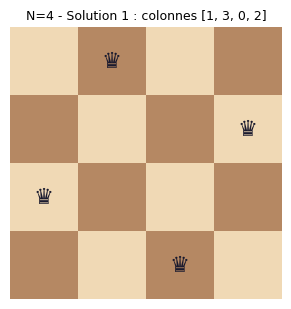

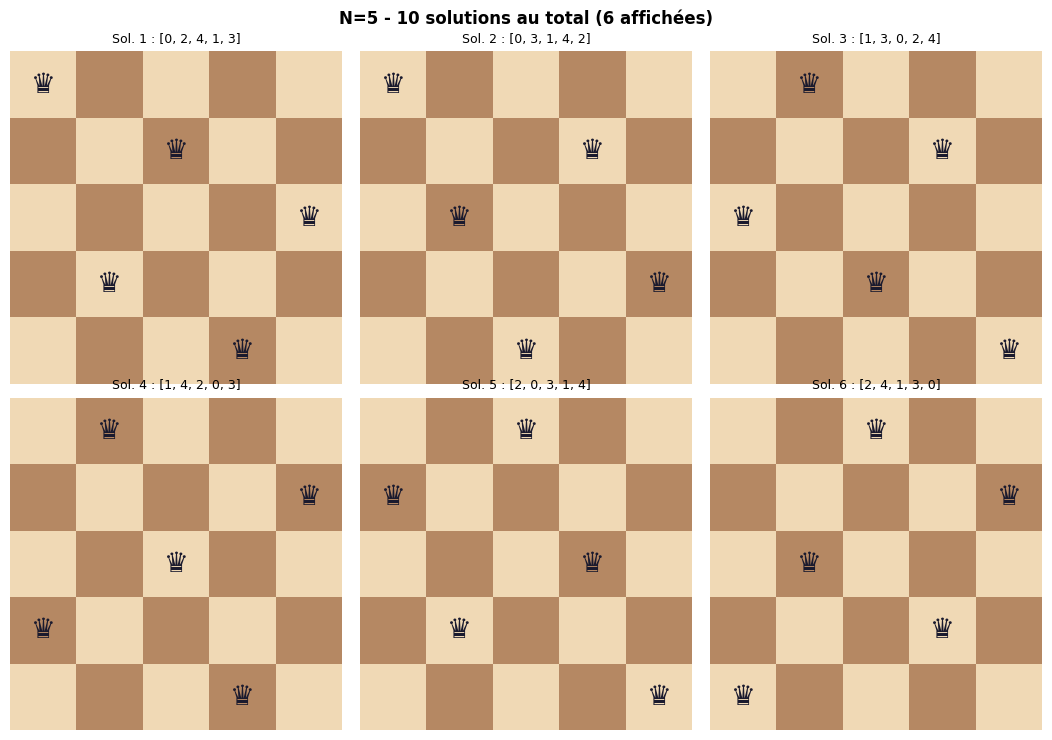

Nombre de solutions par N :
  N=4 : 2 solution(s)
  N=5 : 10 solution(s)
  N=6 : 4 solution(s)
  N=7 : 40 solution(s)
  N=8 : 92 solution(s)


In [11]:
# Visualisation des solutions N-reines
import matplotlib.pyplot as plt


def plot_n_queens(solution: list[int], ax=None, title: str = ''):
    """Affiche un échiquier avec la solution des N-reines sur un axe matplotlib."""
    n = len(solution)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(n * 0.8, n * 0.8))

    # Échiquier
    for row in range(n):
        for col in range(n):
            color = '#f0d9b5' if (row + col) % 2 == 0 else '#b58863'
            ax.add_patch(plt.Rectangle((col, n - 1 - row), 1, 1, fc=color, ec='none'))

    # Reines
    for row, col in enumerate(solution):
        ax.text(col + 0.5, n - 1 - row + 0.5, '♛',
                ha='center', va='center', fontsize=int(n * 4), color='#1a1a2e')

    ax.set_xlim(0, n); ax.set_ylim(0, n)
    ax.set_aspect('equal'); ax.axis('off')
    if title:
        ax.set_title(title, fontsize=9)

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_all_solutions(solutions: list[list[int]], max_display: int = 6):
    """Affiche toutes les solutions (ou les max_display premières)."""
    n = len(solutions[0])
    to_show = solutions[:max_display]
    ncols = min(len(to_show), 3)
    nrows = (len(to_show) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * (n * 0.65 + 0.3), nrows * (n * 0.65 + 0.5)))
    # Normaliser axes en liste plate
    if nrows == 1 and ncols == 1:
        axes_flat = [axes]
    elif nrows == 1:
        axes_flat = list(axes)
    else:
        axes_flat = [ax for row in axes for ax in row]

    for i, sol in enumerate(to_show):
        plot_n_queens(sol, ax=axes_flat[i], title=f'Sol. {i + 1} : {sol}')

    for ax in axes_flat[len(to_show):]:
        ax.axis('off')

    fig.suptitle(f'N={n} - {len(solutions)} solutions au total ({len(to_show)} affichées)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Afficher la première solution pour N=4 en détail
sol4 = results[4]
plot_n_queens(sol4[0], title=f'N=4 - Solution 1 : colonnes {sol4[0]}')

# Afficher toutes les solutions pour N=5
plot_all_solutions(results[5], max_display=6)

# Résumé quantitatif
print("Nombre de solutions par N :")
for n, sols in results.items():
    print(f"  N={n} : {len(sols)} solution(s)")

# PARTIE 5 : DAG et tri topologique

## 5.1 Qu'est-ce qu'un DAG ?

Un **DAG** (*Directed Acyclic Graph*) est un graphe orienté **sans cycle**.

C'est la structure de données qui modélise les **dépendances** : si A doit être exécuté avant B, on trace un arc A → B. L'absence de cycle garantit qu'on peut toujours trouver un ordre d'exécution valide.

### Applications en data engineering

| Outil | Comment le DAG est utilisé |
|---|---|
| **Apache Airflow** | Chaque nœud est une tâche, les arcs encodent les dépendances |
| **dbt** | Chaque nœud est un modèle SQL, les arcs encodent les `ref()` |
| **Apache Spark** | Le plan d'exécution est un DAG de transformations |
| **Git** | L'historique des commits est un DAG |

## 5.2 Tri topologique

Le **tri topologique** ordonne les sommets d'un DAG de façon que chaque arc (u → v) satisfasse : u apparaît **avant** v dans l'ordre.

Il existe deux algorithmes classiques.

### Algorithme de Kahn (BFS)

C’est algorithme assez facile à apréhender. Rappel : un arc A → B signifie que B dépend de A. Autrement dit, A doit être traité avant B.

L'idée : un sommet **sans dépendances** ou dont toutes les dépendances ont été satisfaites peut être exécuté immédiatement. Une fois traité, on le retire (virtuellement) du graphe, ce qui peut libérer de nouveaux sommets.

**Étapes :**

1. Calculer le **in-degree** de chaque sommet (nombre d'arcs entrants), c'est-à-dire le nombre de dépendances qu'il lui reste à satisfaire.
2. Placer dans une file (enqueue) tous les sommets dont le degré entrant vaut 0 (pour tous les sommets avec `in_degree == 0` : aucune dépendance en attente)
3. Tant que la file n'est pas vide :
   - Retirer un sommet `u` de la file (dequeue) et l'ajouter à l'ordre topologique (l'ordre de tri)
   - Pour chaque voisin `v` de `u` : décrémenter `in_degree[v] -= 1` (on retire l'arc u→v virtuellement)
   - Si `in_degree[v] == 0` on ajouter v à la file (plus de dépendances → enqueue v)
4. À la fin :
   - Si tous les sommets ont été traités, l’ordre obtenu est un tri topologique valide (→ DAG valide)
   - Sinon, le graphe contient au moins un cycle → **cycle détecté**
     > En présence d'un cycle, aucun sommet du cycle ne peut jamais atteindre un degré entrant nul, ce qui bloque l'algorithme.


#### Exemple concret
Imaginons une série de tâches A, B, C, D, E et F.

- A doit être effectué avant C et D
- B doit être effectué avant D
- C et D doivent être effectués avant E
- E doit être effectué avant F

Une autre manière de présenter les choses (on explicite les arcs) : 
A → C
A → D
B → D
C → E
D → E
E → F

Ce qu’on peut représenter sous la forme d’un graphe (pour simplifier le dessin on n’a pas représenté les orientations, on considère que chaque arc est orienté de haut en bas) :

```
      A   B
     / \ / 
    C   D
     \ /
      E
      |
      F
```

Suivont l’algorithme pas à pas :

#### Étape 1 : Calcul des in-degree (degrés entrant)

| Sommet | In-degree |
| ------ | --------- |
| A      | 0         |
| B      | 0         |
| C      | 1         |
| D      | 2         |
| E      | 2         |
| F      | 1         |

On peut donc créer immédiatement la file suivane avec les tâches sans dépendance :

```
[A, B]
```

#### Étape 2 : traiter A

On retire A de la file (dequeue) elle eset dans la liste ordre :

```
[A]
```

On supprime virtuellement les arcs :

A → C
A → D

On met à jour la table des degrés entrants :

| Sommet | In-degree |
| ------ | --------- |
|B	|0 |
|C	|0 |
|D	|1 |
|E	|2 |
|F	|1 |


C devient disponible.

On l’ajoute à la file :
```
[B, C]
```

#### Étape 3 : traiter B

On l’ajoute à notre ordre :
```
[A, B]
```
On donc retire les arcs qui en dépendent :

B → D

Ce qui donne les nouveaux degrés :


| Sommet | In-degree |
| ------ | --------- |
|C	|0 |
|D	|0 |
|E	|2 |
|F	|1 |


D devient disponible.

Notre file devient :

[C, D]

#### Étape 4 : traiter C

Notre ordre :
```
[A, B, C]
```
On retire :

C → E

On met à jour nos nouveaux degrés :

| Sommet | In-degree |
| ------ | --------- |
|D	|0 |
|E	|1 |
|F	|1 |


La file :
```
[D]
```

#### Étape 5 : traiter D

Notre ordre :
```
[A, B, C, D]
```

On retire :

D → E

Nouveaux degrés :

| Sommet | In-degree |
| ------ | --------- |
|E	|0 |
|F	|1 |


E devient disponible.

File :
```
[E]
```

#### Étape 6 : traiter E

Ordre :
```
[A, B, C, D, E]
```

On retire :

E → F

Nouveaux degrés :

| Sommet | In-degree |
| ------ | --------- |
|F	|0 |


File :
```
[F]
```

#### Étape 7 : traiter F

Ordre final :

[A, B, C, D, E, F]

La file est vide et tous les sommets ont été traités.

> Notre graphe est bien un DAG !

#### Détection de cycle

Considérons maintenant :

A → B
B → C
C → A

Les degrés entrants valent :

| Sommet | In-degree |
| ------ | --------- |
|A	|1 |
|B	|1 |
|C	|1 |

Aucun sommet n'a un degré entrant nul.

La file est donc vide dès le départ : `[]`.

L'algorithme est bloqué immédiatement et aucun sommet ne peut être traité, le graphe contient donc un cycle !

C'est précisément cette propriété qui permet à l'algorithme de Kahn d'effectuer simultanément un tri topologique et une détection de cycle.

L'algorithme de Kahn est souvent le plus intuitif : on retire progressivement les sommets dont toutes les dépendances ont été satisfaites.

Mais ce n'est pas la seule solution.

En réalité, le parcours DFS possède une propriété remarquable sur les DAG : l'ordre dans lequel les sommets terminent leur exploration contient déjà l'information nécessaire pour construire un tri topologique. Au lieu de suivre les dépendances restantes comme le fait Kahn, nous allons donc utiliser les temps de fin de parcours produits naturellement par le DFS.

### Méthode DFS avec horodatage de fin

Jusqu'à présent, nous avons utilisé le DFS comme une technique de parcours : pré-ordre, in-ordre ou post-ordre permettaient simplement de visiter les nœuds dans différents ordres. Sur un DAG, le DFS devient encore plus intéressant. En observant non pas le moment où l'on découvre un sommet, mais celui où l'on termine complètement son exploration, on peut construire directement un ordre topologique.

Cette méthode constitue une alternative à l'algorithme de Kahn. Cette approche repose sur une propriété fondamentale du DFS dans un DAG :

> Si u → v, le DFS finira toujours de traiter v **avant** u (v est un descendant de u).

Donc : **temps de fin de v < temps de fin de u**. En triant par temps de fin **décroissant**, u vient avant v, on obtient exactement l'ordre topologique voulu.

**Étapes :**

1. Lancer DFS depuis chaque sommet non visité (marquage WHITE/GRAY/BLACK)
2. À la **fin du traitement** de chaque sommet u → empiler u dans `finish_stack`
3. Inverser `finish_stack` → ordre topologique

```
Exemple : A → B → D, A → C → D

DFS depuis A :
  A (GRAY) → B (GRAY) → D (GRAY) → fin D, empile D   [D]
           ← fin B, empile B                           [D, B]
           → C (GRAY) → D déjà BLACK, skip
           ← fin C, empile C                           [D, B, C]
  ← fin A, empile A                                    [D, B, C, A]

Inverser → A C B D 
```

### Implémentations 

In [8]:
from collections import deque


def topological_sort_kahn(graph: Graph) -> Optional[list[str]]:
    """
    Tri topologique par l'algorithme de Kahn (BFS).

    Returns
    -------
    list[str] : ordre topologique, ou None si le graphe contient un cycle.
    """
    in_degree: dict[str, int] = {v: 0 for v in graph.vertices}
    for u in graph.vertices:
        for v in graph.neighbors(u):
            in_degree[v] += 1

    queue: deque[str] = deque(sorted(v for v, d in in_degree.items() if d == 0))
    order: list[str] = []

    while queue:
        u = queue.popleft()
        order.append(u)
        for v in sorted(graph.neighbors(u)):
            in_degree[v] -= 1
            if in_degree[v] == 0:
                queue.append(v)

    return order if len(order) == len(graph.vertices) else None


def topological_sort_dfs(graph: Graph) -> Optional[list[str]]:
    """
    Tri topologique par DFS (horodatage de fin décroissant).

    Returns
    -------
    list[str] : ordre topologique, ou None si le graphe contient un cycle.
    """
    WHITE, GRAY, BLACK = 0, 1, 2
    color: dict[str, int] = {v: WHITE for v in graph.vertices}
    finish_stack: list[str] = []
    has_cycle = [False]

    def dfs_visit(u: str):
        if has_cycle[0]:
            return
        color[u] = GRAY
        for v in graph.neighbors(u):
            if color[v] == GRAY:          # arc arrière → cycle
                has_cycle[0] = True
                return
            if color[v] == WHITE:
                dfs_visit(v)
        color[u] = BLACK
        finish_stack.append(u)            # empilé à la fin du traitement ← horodatage

    for u in sorted(graph.vertices):
        if color[u] == WHITE:
            dfs_visit(u)

    return None if has_cycle[0] else list(reversed(finish_stack))


# ── Démonstration sur le pipeline ────────────────────────────────
pipeline = Graph(directed=True)
for u, v in [
    ('ingestion_logs',      'nettoyage'),
    ('ingestion_users',     'nettoyage'),
    ('nettoyage',           'agregation_sessions'),
    ('nettoyage',           'agregation_achats'),
    ('agregation_sessions', 'rapport_hebdo'),
    ('agregation_achats',   'rapport_hebdo'),
    ('rapport_hebdo',       'export_BI'),
]:
    pipeline.add_edge(u, v)

kahn = topological_sort_kahn(pipeline)
dfs  = topological_sort_dfs(pipeline)
print(f"Kahn (BFS) : {' → '.join(kahn)}")
print(f"DFS        : {' → '.join(dfs)}")
print()
print("Les deux ordres sont valides (plusieurs ordres topologiques peuvent exister).")
print("Propriété commune : chaque tâche apparaît après toutes ses dépendances.")

Kahn (BFS) : ingestion_logs → ingestion_users → nettoyage → agregation_achats → agregation_sessions → rapport_hebdo → export_BI
DFS        : ingestion_users → ingestion_logs → nettoyage → agregation_sessions → agregation_achats → rapport_hebdo → export_BI

Les deux ordres sont valides (plusieurs ordres topologiques peuvent exister).
Propriété commune : chaque tâche apparaît après toutes ses dépendances.


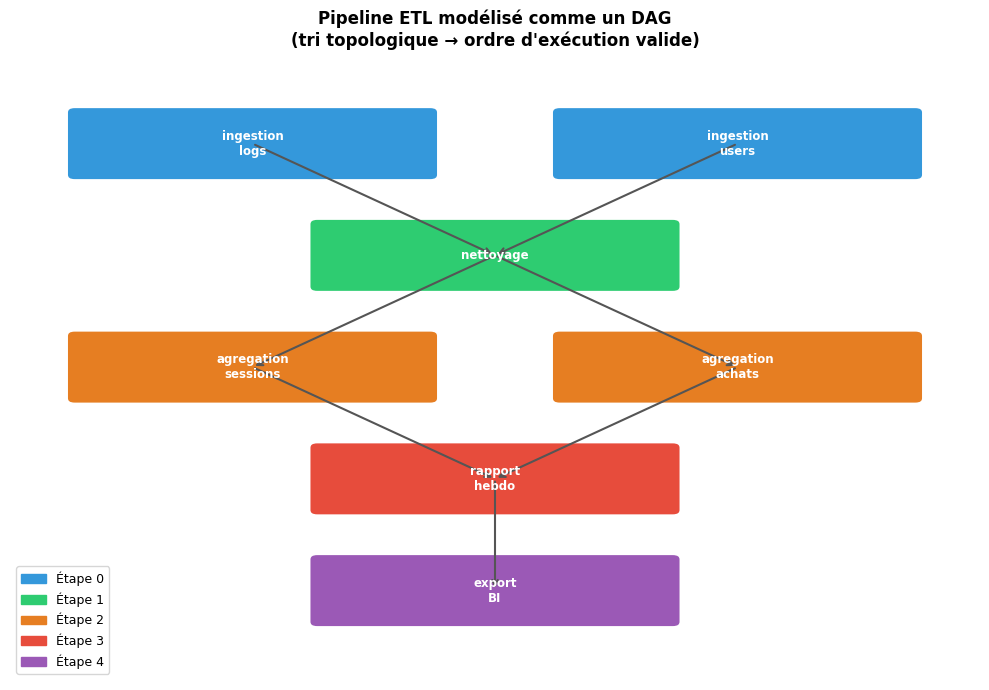

In [9]:
# Visualisation du DAG pipeline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

positions = {
    'ingestion_logs':      (0, 3),
    'ingestion_users':     (3, 3),
    'nettoyage':           (1.5, 2),
    'agregation_sessions': (0, 1),
    'agregation_achats':   (3, 1),
    'rapport_hebdo':       (1.5, 0),
    'export_BI':           (1.5, -1),
}
topo_level = {
    'ingestion_logs': 0, 'ingestion_users': 0,
    'nettoyage': 1,
    'agregation_sessions': 2, 'agregation_achats': 2,
    'rapport_hebdo': 3,
    'export_BI': 4,
}
level_colors_map = {0: '#3498db', 1: '#2ecc71', 2: '#e67e22', 3: '#e74c3c', 4: '#9b59b6'}

fig, ax = plt.subplots(figsize=(10, 7))

for u, v, _ in pipeline.edges:
    x1, y1 = positions[u]; x2, y2 = positions[v]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))

for node, (x, y) in positions.items():
    color = level_colors_map[topo_level[node]]
    ax.add_patch(mpatches.FancyBboxPatch((x-1.1, y-0.28), 2.2, 0.56,
                 boxstyle='round,pad=0.05', fc=color, ec='white', linewidth=2, zorder=2))
    ax.text(x, y, node.replace('_', '\n'), ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=3)

legend_patches = [mpatches.Patch(color=c, label=f'Étape {k}') for k, c in level_colors_map.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9)
ax.set_xlim(-1.5, 4.5); ax.set_ylim(-1.8, 3.8)
ax.axis('off')
ax.set_title("Pipeline ETL modélisé comme un DAG\n(tri topologique → ordre d'exécution valide)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5.3 Propagation d'impact dans un DAG

Dans un pipeline réel, si une tâche **échoue ou est modifiée**, quelles tâches en aval sont impactées ?

Un **BFS** depuis le nœud modifié identifie l'ensemble des **descendants** à invalider ou relancer.

In [10]:
def impact_propagation(graph: Graph, changed_node: str) -> set[str]:
    """
    Retourne l'ensemble des nœuds impactés par un changement
    sur `changed_node` dans un DAG orienté.

    Utilise BFS pour parcourir tous les descendants.
    """
    visited: set[str] = set()
    queue: deque[str] = deque([changed_node])

    while queue:
        u = queue.popleft()
        for v in graph.neighbors(u):
            if v not in visited:
                visited.add(v)
                queue.append(v)

    return visited  # descendants directs et indirects (sans changed_node lui-même)


changed = 'nettoyage'
impacted = impact_propagation(pipeline, changed)

topo_order = topological_sort_kahn(pipeline)
print(f"Si '{changed}' est modifié, les tâches impactées sont (dans l'ordre d'exécution) :")
for task in [t for t in topo_order if t in impacted]:
    print(f"  → {task}")

Si 'nettoyage' est modifié, les tâches impactées sont (dans l'ordre d'exécution) :
  → agregation_achats
  → agregation_sessions
  → rapport_hebdo
  → export_BI


# Conclusion

## Réflexes à développer

> **Représentation :** graphe creux (réseau, pipeline, graphe social) → **liste d'adjacence**. Dense → matrice.

> **Parcours :** besoin du plus court chemin non pondéré → **BFS**. Détection de cycle ou tri topologique → **DFS**.

> **Pipeline data :** dépendances = **DAG**. Ordre d'exécution = **tri topologique**. Propagation d'échec = **BFS** depuis le nœud défaillant.

*Suite : Notebook B : Dijkstra et A\* pour les plus courts chemins pondérés.*